# Session 1 - From a Geoscience Problem to a Machine Learning Problem

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at the Abali meteorological station (Iran)  
**Session length:** 90 minutes  
**Data source (the only one used in this course):** `data/raw/abali.xlsx`

---

## Learning objectives

By the end of this session you will be able to:

1. Translate a geoscience question (*how windy will it be tomorrow morning?*) into a precise machine-learning problem with an explicit target, forecast horizons and evaluation metrics.
2. Open a raw meteorological Excel export, audit it, and explain what is metadata and what is a measurement.
3. Detect and treat, **in memory**, the classic defects of station data: sentinel values, physically impossible readings, duplicate and irregular timestamps.
4. Explain why a 10-minute file must be averaged onto a regular hourly grid *before* any lag feature is built.
5. Describe the diurnal, seasonal and autocorrelation structure of wind speed at Abali.
6. Justify the choice of reference baselines (persistence, climatology) and the roles of MAE and RMSE.

## Prerequisites

- Basic Python, NumPy, pandas and introductory statistics.
- No previous machine-learning experience is assumed.

## Golden rules of this course

- **One dataset only.** Every notebook reads `data/raw/abali.xlsx`. We never mix stations.
- **No file is ever written.** All cleaning, feature engineering and model fitting happen in memory.
- **No future information may enter a feature.** We will check this rule in every session.

---

## 0. How the course is organised

| Session | Notebook | Main idea |
|---|---|---|
| 1 | `01_problem_definition_and_eda_abali.ipynb` | problem definition, raw-data audit, exploratory analysis |
| 2 | `02_data_preparation_features_leakage_abali.ipynb` | features, leakage, chronological splits |
| 3 | `03_baselines_and_classical_ml_abali.ipynb` | baselines, linear/tree/SVR models |
| 4 | `04_ensemble_models_and_tuning_abali.ipynb` | boosting and hyper-parameter search |
| 5 | `05_time_series_forecasting_multi_horizon_abali.ipynb` | walk-forward validation, 3/6/12/24 h horizons |
| 6 | `06_model_interpretation_and_ai_assisted_workflow_abali.ipynb` | interpretation, error regimes, working with LLMs |
| 7 | `07_final_project_pipeline_and_report_abali.ipynb` | final pipeline, single test evaluation, report |

Each notebook is **self-contained**: you can run it top-to-bottom on its own. The small data-loading function is therefore repeated in each notebook - in a real project you would put it in a module, but here self-containedness matters more.

### How to run

1. Open a terminal in the repository root (the folder that contains `data/`, `src/` and `course/`).
2. Start Jupyter: `jupyter lab` (or `jupyter notebook`).
3. Open this notebook and use *Run All*, or step through the cells with Shift+Enter.

> Note on the repository pipeline: the existing modules in `src/` were written for the research pipeline and the loader in `src/data.py` **saves** a cleaned CSV to `data/cleaned/`. For the course we must not create or depend on such files, so the notebooks re-implement the loader here, in memory. The research code is still worth reading for reference.

---

## 1. Setup

We begin with the three things every reproducible notebook needs: **libraries**, **paths** and **seeds**.

- Paths are always relative to the repository root.
- The random seed is fixed so that every student obtains identical numbers.
- Optional libraries are imported inside `try/except` so that the notebook still runs when they are missing.

In [1]:
# ---------------------------------------------------------------------------
# Session 1 setup: libraries, paths, seeds
# ---------------------------------------------------------------------------
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

# --- Optional dependencies --------------------------------------------------
HAS_SNS = False
try:
    import seaborn as sns
    HAS_SNS = True
except Exception as exc:
    print('[optional] seaborn not available:', exc)
    print('           install with:  pip install seaborn      (plots fall back to matplotlib)')

HAS_STATS = False
try:
    import statsmodels.api as sm
    HAS_STATS = True
except Exception as exc:
    print('[optional] statsmodels not available:', exc)
    print('           install with:  pip install statsmodels  (ACF falls back to pandas)')

# Data paths. The primary candidate is relative to the repository root; the
# alternatives keep the notebook working when Jupyter starts the kernel inside
# course/notebooks/ (JupyterLab does this by default). No absolute paths.
RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError(
        'Could not find abali.xlsx. Expected at ' + candidates[0] +
        ' relative to the repository root (the folder holding data/, src/, course/).'
    )


RAW_PATH = resolve_raw_path()

print()
print('Python     :', sys.version.split()[0])
print('pandas     :', pd.__version__)
print('numpy      :', np.__version__)
print('matplotlib :', matplotlib.__version__)
print('seaborn    :', sns.__version__ if HAS_SNS else 'not installed')
print()
print('random seed:', SEED)

using raw data file: ../../data/raw/abali.xlsx

Python     : 3.13.7
pandas     : 2.3.2
numpy      : 2.5.2
matplotlib : 3.11.1
seaborn    : 0.13.2

random seed: 42


---

## 2. Meet the raw file

### 2.1 The geoscience object

Abali is a mountain station in the Alborz range north-east of Tehran, at roughly 2000 m above sea level. Its wind climate matters for air-quality transport, wind-energy screening and aviation.

The station logger writes a row every **10 minutes**. That is the native resolution: 6 records per hour, 144 per day.

Why does the resolution matter so early?

- A 10-minute series has *six times* the rows of an hourly series but almost no extra information - neighbouring records are extremely correlated.
- Scientific practice for wind forecasting at these horizons is hourly: lag 1 = 1 hour.
- If we later talk about a *3-hour* forecast built on 10-minute data, every lag and rolling window becomes confusing (lag 6 = 1 hour).

We therefore read the 10-minute file, audit it, and then average it onto an hourly grid.

### 2.2 Read-only inspection

The cells below only *read* the file. Nothing is written to disk.

In [2]:
# Read-only: we open the raw export and never write back to it.
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        'Cannot find ' + RAW_PATH + '. Start Jupyter from the repository root '
        '(the folder that contains data/, src/ and course/).'
    )

raw = pd.read_excel(RAW_PATH)          # 10-minute records, saved newest-first
print('raw file  :', RAW_PATH)
print('raw shape :', raw.shape)
print('rows      :', '{:,}'.format(len(raw)))
print('columns   :', len(raw.columns))
print()
for i, col in enumerate(raw.columns, 1):
    print('  {:2d}. {}'.format(i, col))

raw.head(3)                            # last expression in a cell is displayed

raw file  : ../../data/raw/abali.xlsx
raw shape : (61353, 21)
rows      : 61,353
columns   : 21

   1. WMOCode
   2. StationName
   3. VendorName
   4. StationTypeName
   5. DateTimes
   6. ShamsiDateTime
   7. Air Pressure(hPa)
   8. Air Temperature(C)
   9. Radiation(w/m2)
  10. Rain Sum(mm)
  11. rel. Humidity(%)
  12. Soil Temperature 100cm(C)
  13. Soil Temperature 10cm(C)
  14. Soil Temperature 20cm(C)
  15. Soil Temperature 30cm(C)
  16. Soil Temperature 50cm(C)
  17. Soil Temperature 5cm(C)
  18. Surface Temperature(C)
  19. Total Radiation(w/m2)
  20. Wind Direction(D)
  21. Wind Speed(m/s)


,WMOCode,StationName,VendorName,StationTypeName,DateTimes,ShamsiDateTime,Air Pressure(hPa),Air Temperature(C),Radiation(w/m2),Rain Sum(mm),rel. Humidity(%),Soil Temperature 100cm(C),Soil Temperature 10cm(C),Soil Temperature 20cm(C),Soil Temperature 30cm(C),Soil Temperature 50cm(C),Soil Temperature 5cm(C),Surface Temperature(C),Total Radiation(w/m2),Wind Direction(D),Wind Speed(m/s)
0,40755,آبعلي,Vaisala,SYNOPTIC,2025-03-10 23:50:10,1403/12/20 23:50:10,757.9,0.9,67.0,NaN,NaN,2.0,-0.4,-0.4,-0.5,0.2,-0.2,-0.3,1414.3,230.0,0.0
1,40755,آبعلي,Vaisala,SYNOPTIC,2025-03-10 23:40:10,1403/12/20 23:40:10,758.0,1.0,67.0,NaN,NaN,2.0,-0.4,-0.4,-0.5,0.2,-0.3,-0.3,1374.3,193.0,0.0
2,40755,آبعلي,Vaisala,SYNOPTIC,2025-03-10 23:30:10,1403/12/20 23:30:10,757.9,1.1,67.0,NaN,NaN,2.0,-0.4,-0.4,-0.5,0.2,-0.3,-0.4,1334.3,213.0,1.0


The export contains 21 columns, but only six of them are *measurements we will use*.

| Column | Role |
|---|---|
| `DateTimes` | timestamp of the observation |
| `Wind Speed(m/s)` | **target variable** - what we want to predict |
| `Wind Direction(D)` | feature (circular!) |
| `Air Pressure(hPa)` | feature |
| `Air Temperature(C)` | feature |
| `rel. Humidity(%)` | feature |
| `WMOCode`, `StationName`, `VendorName`, `StationTypeName` | metadata (constant, useless as features) |
| `ShamsiDateTime` | duplicate of the timestamp in the Jalali calendar (not needed) |
| `Radiation`, `Total Radiation`, `Rain Sum`, soil/surface temperatures | extra sensors, often missing; we keep them out of the first pipeline for clarity |

**Check for understanding:** why would `WMOCode` be useless as a feature even though it is numeric? *Because it is constant for this station - it carries no information that can separate windy from calm hours.*

In [3]:
# Timestamps: parse, sort, and verify the real sampling interval.
raw['datetime'] = pd.to_datetime(raw['DateTimes'], errors='coerce')

print('unparsable timestamps        :', int(raw['datetime'].isna().sum()))
print('range as stored in the file  :', raw['datetime'].min(), '->', raw['datetime'].max())
print('is the first row the NEWEST? :', bool(raw['datetime'].iloc[0] > raw['datetime'].iloc[-1]))

# The export arrives in reverse chronological order. Building a lag feature before
# sorting would silently create the worst possible leakage. Sorting comes first.
raw = raw.sort_values('datetime').reset_index(drop=True)
print()
print('after sorting                :', raw['datetime'].iloc[0], '->', raw['datetime'].iloc[-1])

interval = raw['datetime'].diff().dropna()
print()
print('most common spacings between consecutive records:')
print(interval.value_counts().head(6).to_string())

span_hours = (raw['datetime'].max() - raw['datetime'].min()) / pd.Timedelta(hours=1)
print()
print('span                                       : {:.1f} hours ({:.1f} days)'.format(span_hours, span_hours / 24.0))
print('rows expected at a perfect 10-minute cadence:', int(span_hours * 6) + 1)
print('rows actually present                      :', len(raw))
print('duplicate timestamps                       :', int(raw['datetime'].duplicated().sum()))

unparsable timestamps        : 0
range as stored in the file  : 2024-01-01 00:00:10 -> 2025-03-10 23:50:10
is the first row the NEWEST? : True

after sorting                : 2024-01-01 00:00:10 -> 2025-03-10 23:50:10

most common spacings between consecutive records:
datetime
0 days 00:10:00    59093
0 days 00:09:59      886
0 days 00:10:01      885
0 days 00:20:00      408
0 days 00:30:00       23
0 days 00:20:01       10

span                                       : 10439.8 hours (435.0 days)
rows expected at a perfect 10-minute cadence: 62640
rows actually present                      : 61353
duplicate timestamps                       : 0


C:\Users\Amir\AppData\Local\Temp\ipykernel_5888\1090359821.py:19: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  span_hours = (raw['datetime'].max() - raw['datetime'].min()) / pd.Timedelta(hours=1)


### Teaching point - why the reverse order is dangerous

A `shift(1)` on data stored newest-first does **not** give you the previous hour: it gives you the *next* hour. The model would then be trained to predict the past from the future, and its validation score would be excellent and completely meaningless.

This is our first encounter with the central theme of the course:

> **Leakage is usually not a modelling mistake - it is an ordering, alignment or bookkeeping mistake.**

The spacings above show that roughly 0.2 % of records are late or early by a few seconds and that a few gaps are much larger. After hourly averaging most of this disappears, but we must verify that, not assume it.

In [4]:
# Canonical column names, then value-level quality control.
# Of the 21 columns in the file we keep exactly these six.
COL_MAP = {
    'DateTimes': 'datetime',
    'Wind Speed(m/s)': 'wind_speed_ms',
    'Wind Direction(D)': 'wind_direction_deg',
    'Air Pressure(hPa)': 'pressure_hpa',
    'Air Temperature(C)': 'temperature_c',
    'rel. Humidity(%)': 'humidity',
}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']

absent = [c for c in COL_MAP if c not in raw.columns]
print('expected raw columns that are absent:', absent)

df = raw[list(COL_MAP)].rename(columns=COL_MAP).copy()
for c in DATA_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')   # Excel sometimes returns text

print()
print('value ranges in the raw 10-minute file:')
print(df[DATA_COLS].agg(['min', 'max']).T.to_string())

print()
print('records holding a -99999 style sentinel (value <= -900):')
print((df[DATA_COLS] <= -900).sum().to_string())

print()
print('Watch the humidity column: with the sentinel still inside, its mean is')
print('{:.2f} %, which is physically absurd for a mountain station.'.format(df['humidity'].mean()))

expected raw columns that are absent: []

value ranges in the raw 10-minute file:
                        min    max
wind_speed_ms           0.0   18.8
wind_direction_deg      1.0  360.0
pressure_hpa          744.8  766.0
temperature_c         -18.3   32.7
humidity           -99999.0  100.0

records holding a -99999 style sentinel (value <= -900):
wind_speed_ms          0
wind_direction_deg     0
pressure_hpa           0
temperature_c          0
humidity              22

Watch the humidity column: with the sentinel still inside, its mean is
12.21 %, which is physically absurd for a mountain station.


**Two defects are now visible, and both are typical of real station data:**

1. **Sentinel values.** The logger writes `-99999` when the humidity sensor fails. A naive `df.mean()` or a model trained on the raw column would treat those hours as *extremely dry* - a physically impossible but numerically harmless-looking value.
2. **Out-of-range values.** We can detect most of them with physical bounds rather than statistics:

| Variable | Physically acceptable range | Reason |
|---|---|---|
| wind speed | 0 - 60 m/s | negative speed is impossible |
| wind direction | 0 - 360 deg | circular quantity |
| pressure | 500 - 1100 hPa | Abali is near 2000 m a.s.l., so ~750-800 hPa, not 1013 hPa |
| temperature | -60 - +60 degC | sanity envelope for a mid-latitude mountain site |
| relative humidity | 0 - 100 % | a ratio |

> **Scientific habit:** never fix a bad value with a guess that you cannot defend in a paper. Marking a physically impossible reading as *missing* is a defensible, documented decision; silently replacing it with the mean is not.

In [5]:
# Physically impossible values -> NaN (in memory only).
PHYSICAL_BOUNDS = {
    'wind_speed_ms': (0.0, 60.0),
    'wind_direction_deg': (0.0, 360.0),
    'pressure_hpa': (500.0, 1100.0),
    'temperature_c': (-60.0, 60.0),
    'humidity': (0.0, 100.0),
}

qc_rows = []
for c, (lo, hi) in PHYSICAL_BOUNDS.items():
    n_below = int((df[c] < lo).sum())
    n_above = int((df[c] > hi).sum())
    qc_rows.append({'column': c, 'valid_min': lo, 'valid_max': hi, 'below': n_below, 'above': n_above})
    df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan

qc = pd.DataFrame(qc_rows)
print(qc.to_string(index=False))

hum = qc.set_index('column').loc['humidity']
print()
print('humidity: {:d} impossible values set to NaN; the column mean is now {:.2f} %'.format(
    int(hum['below'] + hum['above']), df['humidity'].mean()))

            column  valid_min  valid_max  below  above
     wind_speed_ms        0.0       60.0      0      0
wind_direction_deg        0.0      360.0      0      0
      pressure_hpa      500.0     1100.0      0      0
     temperature_c      -60.0       60.0      0      0
          humidity        0.0      100.0     22      0

humidity: 22 impossible values set to NaN; the column mean is now 50.46 %


---

## 3. One clean hourly series, built in memory

The function below is the **only** data-preparation code you need for the whole course. It is repeated (unchanged) at the top of every notebook so that each one is self-contained.

| Step | What it does | Why it matters |
|---|---|---|
| 1 | read the Excel file | single source of truth |
| 2 | keep + rename six columns | explicit, documented column contract |
| 3 | sentinel and range check -> `NaN` | keeps impossible numbers out of the statistics |
| 4 | drop unusable and duplicate timestamps | one row per time step is a precondition for lag features |
| 5 | average 10-minute records to hourly means | matches the native forecasting resolution |
| 6 | reindex onto a *perfect* hourly grid | makes gaps explicit instead of invisible |
| 7 | interpolate only **short** gaps (<= 2 h) of auxiliary variables | repairs trivial sensor dropouts without inventing the target |

The last point is a scientific decision, not a technical one. Wind speed is our **target**: we must never fabricate it. Pressure, temperature, humidity and wind direction are **inputs**; filling a one- or two-hour drop-out with a linear interpolation is standard practice and far less damaging than deleting 24 rows of a rolling window because of a two-hour outage.

We also keep `n_obs`, the number of 10-minute records that went into each hourly mean. It is a quality flag, **not** a feature: missingness at a station correlates with equipment problems, so using it as an input would teach the model about the logger rather than about the atmosphere.

In [6]:
def load_abali_hourly(path=RAW_PATH, verbose=True):
    """Load data/raw/abali.xlsx and return a clean HOURLY DataFrame.

    Everything happens in memory: no file is created or modified.

    Steps
    -----
    1. read the 10-minute Excel export
    2. keep and rename the six columns used by the course
    3. sentinel values and out-of-range values -> NaN
    4. drop unusable timestamps and duplicate timestamps
    5. average the 10-minute records into 1-hour means
    6. reindex onto a perfect hourly grid (gaps stay visible as NaN)
    7. linear interpolation of SHORT gaps (<= 2 h) in auxiliary variables only

    Returns
    -------
    hourly : DataFrame
        Indexed by datetime, columns DATA_COLS plus the flag 'n_obs'
        (number of 10-minute records that contributed to each hour).
    """
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')

    # 1-2. read, select, rename
    out = pd.read_excel(path)
    out = out[list(COL_MAP)].rename(columns=COL_MAP)

    # 3. types, sentinels and physical bounds
    out['datetime'] = pd.to_datetime(out['datetime'], errors='coerce')
    for c in DATA_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out[DATA_COLS] = out[DATA_COLS].mask(out[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        out[c] = out[c].mask((out[c] < lo) | (out[c] > hi))

    # 4. timestamps
    n_bad_time = int(out['datetime'].isna().sum())
    n_dupes = int(out['datetime'].duplicated().sum())
    out = out.dropna(subset=['datetime'])
    out = out.sort_values('datetime').drop_duplicates(subset='datetime', keep='first')

    # 5. 10-minute -> hourly mean, plus a record count per hour
    g = out.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()

    # 6. perfect hourly grid: a missing hour must be visible as NaN, not absent
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    n_obs = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'

    # 7. short-gap repair for auxiliary variables; the target is never filled
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    hourly['n_obs'] = n_obs

    if verbose:
        steps = hourly.index.to_series().diff().dropna()
        print('hourly rows                     :', len(hourly))
        print('hourly range                    :', hourly.index.min(), '->', hourly.index.max())
        print('steps that are not exactly 1 h  :', int((steps != pd.Timedelta(hours=1)).sum()))
        print('unusable / duplicate timestamps :', n_bad_time, '/', n_dupes)
        print()
        miss = pd.DataFrame({
            'missing_hours': hourly[DATA_COLS].isna().sum(),
            'missing_pct': 100.0 * hourly[DATA_COLS].isna().mean(),
        })
        print('missing hours per variable (after 10-minute averaging):')
        print(miss.round(3).to_string())
        print()
        counts = hourly['n_obs'].value_counts().sort_index()
        print('how many 10-minute records contributed to each hour   :')
        print({int(k): int(v) for k, v in counts.items()})
        print('(a full hour has 6 records; an hour with 0 records is a real gap)')
    return hourly


hourly = load_abali_hourly()

hourly rows                     : 10440
hourly range                    : 2024-01-01 00:00:00 -> 2025-03-10 23:00:00
steps that are not exactly 1 h  : 0
unusable / duplicate timestamps : 0 / 0

missing hours per variable (after 10-minute averaging):
                    missing_hours  missing_pct
wind_speed_ms                 111        1.063
wind_direction_deg             94        0.900
pressure_hpa                   94        0.900
temperature_c                  94        0.900
humidity                      442        4.234

how many 10-minute records contributed to each hour   :
{0: 111, 1: 8, 2: 10, 3: 18, 4: 24, 5: 444, 6: 9825}
(a full hour has 6 records; an hour with 0 records is a real gap)


C:\Users\Amir\AppData\Local\Temp\ipykernel_5888\3335317446.py:63: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  print('steps that are not exactly 1 h  :', int((steps != pd.Timedelta(hours=1)).sum()))


**Read that output carefully - it is the whole quality report of the dataset.**

- 10,440 hourly rows cover 2024-01-01 00:00 to 2025-03-10 23:00 with **zero** non-hourly steps: the grid is regular.
- Wind speed is missing in ~1 % of hours. Most hours have all six 10-minute records.
- Humidity is the least reliable variable (~4 % missing after cleaning).

**Check for understanding:** if we had *not* reindexed onto a perfect grid, what would `hourly['wind_speed_ms'].shift(1)` mean across a six-hour outage? *Nothing - it would silently jump over the outage, so 'one hour earlier' would actually be 'seven hours earlier'. The lag feature would be wrong exactly where the data are worst.*

In [ ]:
def missing_runs(series):
    """Return [(start, end, length_hours)] for every contiguous NaN run."""
    flags = series.isna().values
    runs = []
    start = None
    for i, flag in enumerate(flags):
        if flag and start is None:
            start = i
        elif (not flag) and start is not None:
            runs.append((series.index[start], series.index[i - 1], i - start))
            start = None
    if start is not None:
        runs.append((series.index[start], series.index[-1], len(flags) - start))
    return runs


print('Longest wind-speed gaps on the hourly grid:')
for start, end, length in sorted(missing_runs(hourly['wind_speed_ms']), key=lambda t: -t[2])[:10]:
    print('  {:>4d} h   {} -> {}'.format(length, start, end))

print()
print('total missing wind-speed hours :', int(hourly['wind_speed_ms'].isna().sum()))
print('shortest / longest gap (hours) :', sorted(len(r) for r in missing_runs(hourly['wind_speed_ms']))[:1],
      sorted(len(r) for r in missing_runs(hourly['wind_speed_ms']))[-1:])

print()
print('Gaps longer than 12 h (probable instrument or telemetry outage):')
long_gaps = [r for r in missing_runs(hourly['wind_speed_ms']) if r[2] > 12]
for start, end, length in long_gaps:
    print('  {:>4d} h   {} -> {}'.format(length, start, end))
print('count:', len(long_gaps))

### Reading the gap pattern like a scientist

- Many gaps are **one or two hours long** - scheduled maintenance, a reset, or a dropped transmission. These are the ones our short-gap interpolation handles for the *auxiliary* variables.
- A few gaps are **longer than a day** - those are genuine outages. Any feature whose window crosses them must become `NaN` and the row must be dropped, which is exactly what Session 2 does.
- Gaps bear no relation to meteorology, so a model must never be allowed to learn from their *location*. That is why `n_obs` is excluded from the feature set.

### A warning about zeros

On the hourly grid roughly 1 % of hours have exactly **0.00 m/s**. Is that a calm hour or a frozen anemometer?

- A cup anemometer with a dead sensor usually reports a *constant* value, often exactly 0, for many consecutive hours.
- Genuine calm at a mountain station is common at night but rarely lasts all day.

We do not delete the zeros - we flag them and check them again in Session 6 when we analyse residuals by wind regime. **Deciding that data are wrong is a scientific judgement, and it must be documented.**

In [7]:
# Descriptive statistics on the clean hourly grid.
stats = hourly[DATA_COLS].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
print(stats.round(3).to_string())

ws = hourly['wind_speed_ms']
print()
print('mean wind speed        : {:.3f} m/s'.format(ws.mean()))
print('median wind speed      : {:.3f} m/s'.format(ws.median()))
print('standard deviation     : {:.3f} m/s'.format(ws.std()))
print('skewness               : {:+.3f}   (right-skewed: calm hours dominate, storms are rare)'.format(ws.skew()))
print('exactly 0.00 m/s       : {:.2%} of hours'.format(float((ws == 0).mean())))
print('above 8 m/s            : {:.2%} of hours'.format(float((ws > 8).mean())))
print('maximum hourly wind    : {:.2f} m/s'.format(ws.max()))
print()
print('Because of the skew, the mean is a poor summary of a typical hour:')
print('mean = {:.2f} m/s but median = {:.2f} m/s.'.format(ws.mean(), ws.median()))
print('This asymmetry matters later: MAE and RMSE will weight the rare windy hours differently.')

                      count     mean     std      min       5%      25%      50%      75%      95%      max
wind_speed_ms       10329.0    2.493   2.379    0.000    0.167    0.883    1.967    3.300    6.933   18.080
wind_direction_deg  10346.0  214.520  61.598    7.333   67.667  212.167  234.333  246.333  270.667  355.833
pressure_hpa        10346.0  758.392   3.427  744.950  752.100  756.300  758.800  760.850  763.400  765.983
temperature_c       10346.0    7.203  10.159  -17.217   -6.950   -1.083    5.483   15.650   24.717   32.317
humidity             9998.0   52.014  23.100    8.000   20.667   34.333   48.000   66.200   99.885  100.000

mean wind speed        : 2.493 m/s
median wind speed      : 1.967 m/s
standard deviation     : 2.379 m/s
skewness               : +2.360   (right-skewed: calm hours dominate, storms are rare)
exactly 0.00 m/s       : 0.92% of hours
above 8 m/s            : 3.84% of hours
maximum hourly wind    : 18.08 m/s

Because of the skew, the mean is a poor sum

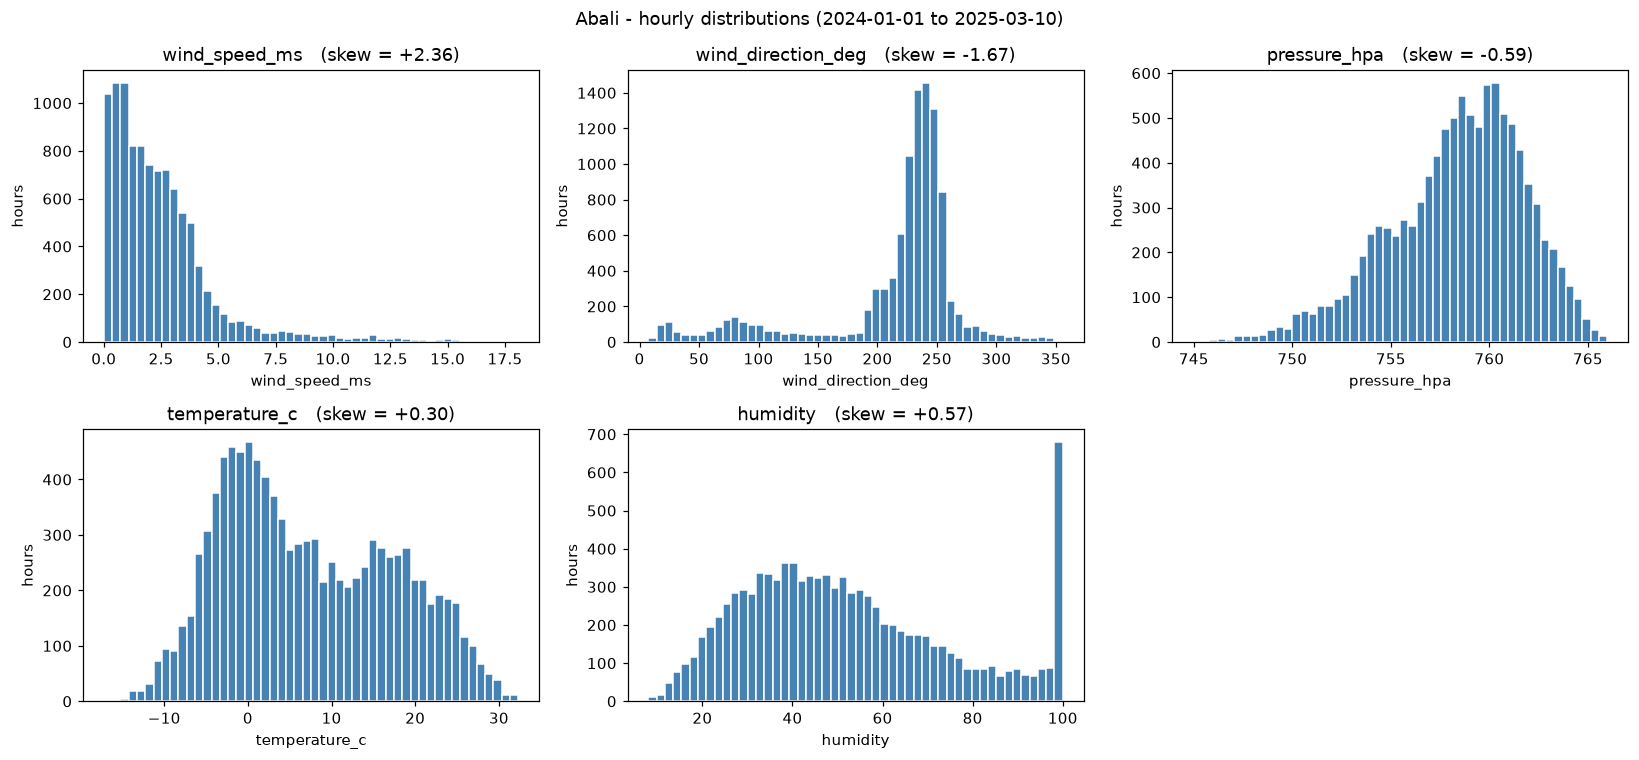

Wind speed is right-skewed: a long tail of rare strong-wind hours.
Wind direction is bimodal, which is a physical fact, not an error: the
Abali valley channel directs most flow from a narrow range of directions.


In [8]:
# Distributions of the five variables we will use.
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), DATA_COLS):
    s = hourly[c].dropna()
    ax.hist(s, bins=50, color='steelblue', edgecolor='white')
    ax.set_title('{}   (skew = {:+.2f})'.format(c, s.skew()))
    ax.set_xlabel(c)
    ax.set_ylabel('hours')
axes.ravel()[-1].axis('off')          # five variables, six panels
plt.suptitle('Abali - hourly distributions (2024-01-01 to 2025-03-10)')
plt.tight_layout()
plt.show()

print('Wind speed is right-skewed: a long tail of rare strong-wind hours.')
print('Wind direction is bimodal, which is a physical fact, not an error: the')
print('Abali valley channel directs most flow from a narrow range of directions.')

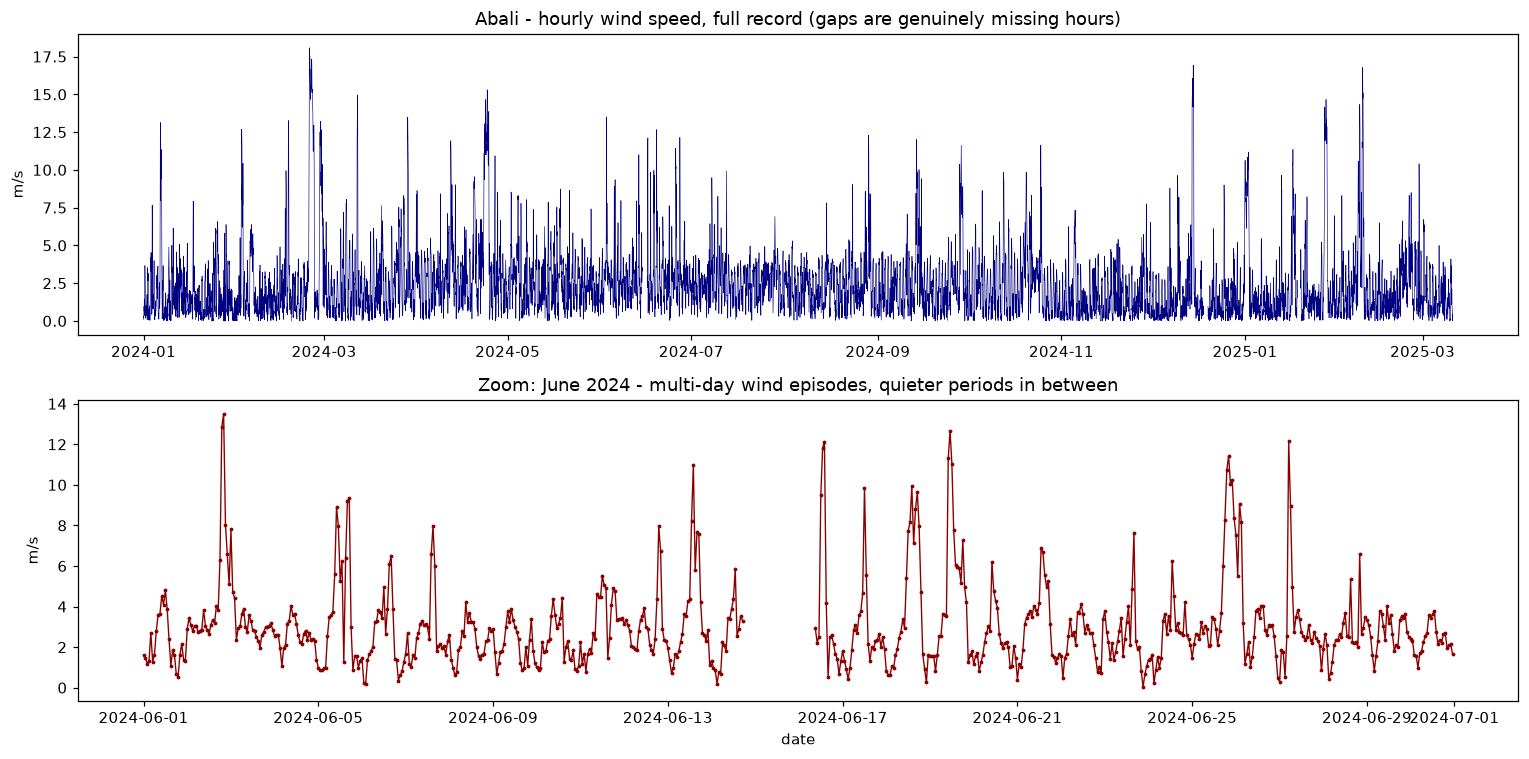

What to notice in the zoom:
  1. Wind comes in episodes lasting several hours or days - that is why a
     lag of the current hour already contains a lot of information.
  2. Day-to-day changes are smooth; hour-to-hour changes are small.
  3. Nothing here is white noise. A forecasting model can beat a coin flip.


In [9]:
# The same wind speed, seen at two time scales.
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(hourly.index, hourly['wind_speed_ms'], lw=0.4, color='navy')
axes[0].set_title('Abali - hourly wind speed, full record (gaps are genuinely missing hours)')
axes[0].set_ylabel('m/s')

june = hourly.loc['2024-06-01':'2024-06-30']
axes[1].plot(june.index, june['wind_speed_ms'], lw=0.9, marker='.', ms=3, color='darkred')
axes[1].set_title('Zoom: June 2024 - multi-day wind episodes, quieter periods in between')
axes[1].set_ylabel('m/s')
axes[1].set_xlabel('date')

plt.tight_layout()
plt.show()

print('What to notice in the zoom:')
print('  1. Wind comes in episodes lasting several hours or days - that is why a')
print('     lag of the current hour already contains a lot of information.')
print('  2. Day-to-day changes are smooth; hour-to-hour changes are small.')
print('  3. Nothing here is white noise. A forecasting model can beat a coin flip.')

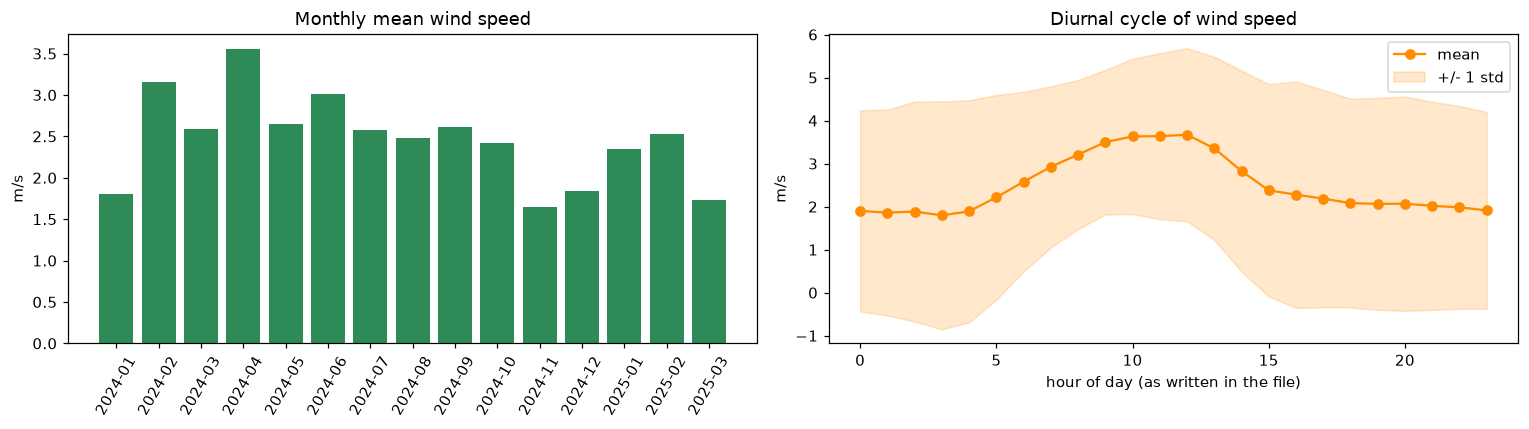

           mean  median    std  count
datetime                             
0         1.901   1.200  2.337    431
1         1.861   1.133  2.394    431
2         1.885   1.060  2.556    431
3         1.797   0.937  2.649    430
4         1.891   1.092  2.580    430
5         2.216   1.667  2.379    431
6         2.579   2.267  2.088    429
7         2.923   2.683  1.873    429
8         3.210   3.075  1.733    430
9         3.499   3.450  1.680    432
10        3.632   3.483  1.806    430
11        3.637   3.433  1.931    429
12        3.672   3.350  2.010    429
13        3.354   2.983  2.128    429
14        2.827   2.433  2.335    431
15        2.378   1.700  2.470    431
16        2.279   1.400  2.629    431
17        2.185   1.450  2.530    431
18        2.082   1.271  2.427    430
19        2.063   1.308  2.463    430
20        2.068   1.350  2.489    431
21        2.018   1.317  2.420    431
22        1.984   1.317  2.357    431
23        1.913   1.283  2.286    431

Take-away: 

In [10]:
# Monthly and diurnal structure: the two strongest periodicities in this dataset.
monthly = hourly['wind_speed_ms'].resample('MS').mean()
diurnal = hourly['wind_speed_ms'].groupby(hourly.index.hour).agg(['mean', 'median', 'std', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly.index.strftime('%Y-%m'), monthly.values, color='seagreen')
axes[0].set_title('Monthly mean wind speed')
axes[0].set_ylabel('m/s')
axes[0].tick_params(axis='x', rotation=60)

axes[1].plot(diurnal.index, diurnal['mean'], marker='o', color='darkorange', label='mean')
axes[1].fill_between(diurnal.index, diurnal['mean'] - diurnal['std'], diurnal['mean'] + diurnal['std'],
                     alpha=0.2, color='darkorange', label='+/- 1 std')
axes[1].set_title('Diurnal cycle of wind speed')
axes[1].set_xlabel('hour of day (as written in the file)')
axes[1].set_ylabel('m/s')
axes[1].legend()
plt.tight_layout()
plt.show()

print(diurnal.round(3).to_string())
print()
print('Take-away: there is a clear diurnal rhythm and a seasonal contrast between')
print('the windy spring/summer months and the quieter winter months.')
print('Time-of-day and time-of-year are therefore legitimate features - they are')
print('known in advance and need no future observation.')

> **Caveat worth writing in your report:** the export does not document its time zone. All hours below are the *local clock time as written in the file*. A 3-hour unlabelled offset would shift the diurnal curve but would not change any of the modelling logic.

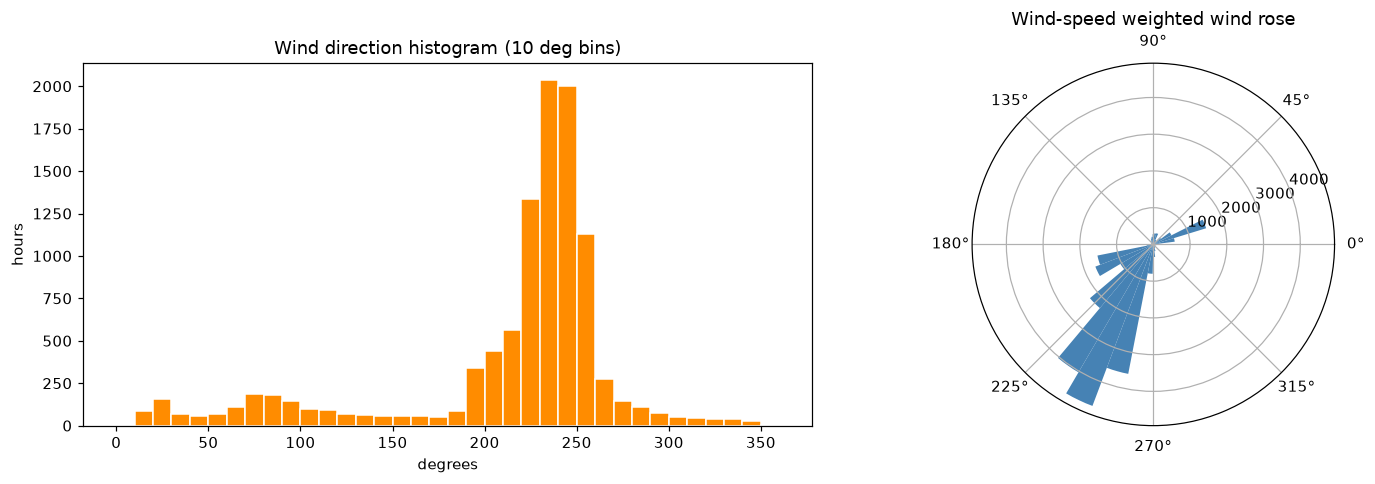

mean of the raw degrees : 214.5 deg
circular mean (vector average): 233.2 deg

The two numbers disagree, and the plain arithmetic mean is the wrong one:
averaging 350 deg and 10 deg as numbers gives 180 deg, the opposite direction.

From Session 2 onward we therefore never use raw degrees as a feature.
We encode the direction as two components:
    wind_dir_sin = sin(radians(direction))
    wind_dir_cos = cos(radians(direction))
Both 0 deg and 360 deg map to (sin, cos) = (0, 1): the wraparound disappears.


In [11]:
# Wind direction is a CIRCULAR variable.
# 359 deg and 1 deg are 2 deg apart, but as plain numbers they look maximally different.
direction = hourly['wind_direction_deg'].dropna()
speed = hourly['wind_speed_ms'].reindex(direction.index)

fig = plt.figure(figsize=(14, 4.5))
ax0 = fig.add_subplot(1, 2, 1)
ax0.hist(direction, bins=36, range=(0, 360), color='darkorange', edgecolor='white')
ax0.set_title('Wind direction histogram (10 deg bins)')
ax0.set_xlabel('degrees')
ax0.set_ylabel('hours')

ax1 = fig.add_subplot(1, 2, 2, projection='polar')
theta = np.radians(direction.values)
ax1.hist(theta, bins=36, weights=speed.fillna(0).values, color='steelblue')
ax1.set_title('Wind-speed weighted wind rose')
plt.tight_layout()
plt.show()

print('mean of the raw degrees : {:.1f} deg'.format(direction.mean()))
print('circular mean (vector average): {:.1f} deg'.format(
    np.degrees(np.arctan2(np.sin(theta).mean(), np.cos(theta).mean())) % 360))
print()
print('The two numbers disagree, and the plain arithmetic mean is the wrong one:')
print('averaging 350 deg and 10 deg as numbers gives 180 deg, the opposite direction.')
print()
print('From Session 2 onward we therefore never use raw degrees as a feature.')
print('We encode the direction as two components:')
print('    wind_dir_sin = sin(radians(direction))')
print('    wind_dir_cos = cos(radians(direction))')
print('Both 0 deg and 360 deg map to (sin, cos) = (0, 1): the wraparound disappears.')

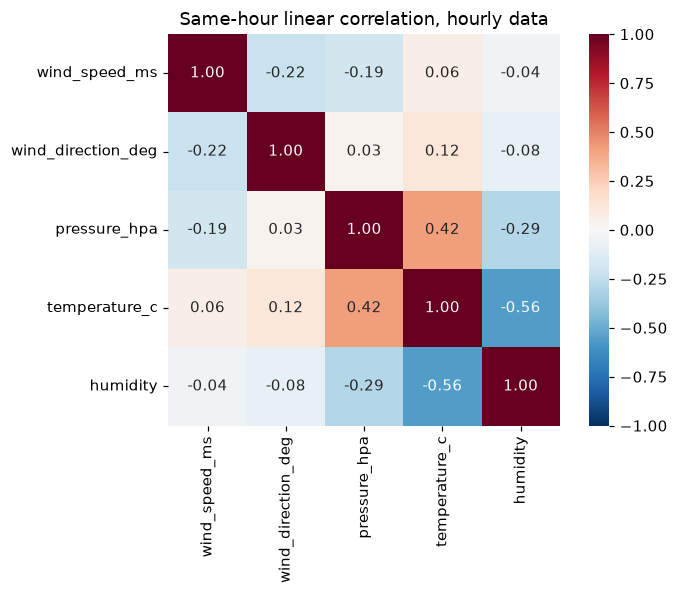

Correlation with same-hour wind speed:
wind_speed_ms         1.000
temperature_c         0.064
humidity             -0.040
pressure_hpa         -0.190
wind_direction_deg   -0.222

exactly the mistake described above. Treat the wind-direction row with care:
a near-zero correlation with a circular variable often means "the effect
wraps around", not "no relationship". The wind rose already showed a real one.


In [12]:
# Correlation between variables at the SAME hour.
corr = hourly[DATA_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
if HAS_SNS:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=ax)
else:
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr)))
    ax.set_yticklabels(corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, '{:.2f}'.format(corr.values[i, j]), ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Same-hour linear correlation, hourly data')
plt.tight_layout()
plt.show()

print('Correlation with same-hour wind speed:')
print(corr['wind_speed_ms'].sort_values(ascending=False).round(3).to_string())
print()
print('Warning: this table lets wind_direction_deg in as a linear number, which is')
print('exactly the mistake described above. Treat the wind-direction row with care:')
print('a near-zero correlation with a circular variable often means "the effect')
print('wraps around", not "no relationship". The wind rose already showed a real one.')

autocorrelation of hourly wind speed:
1      0.895
2      0.778
3      0.678
6      0.444
12     0.228
24     0.258
48     0.083
72     0.156
168    0.086


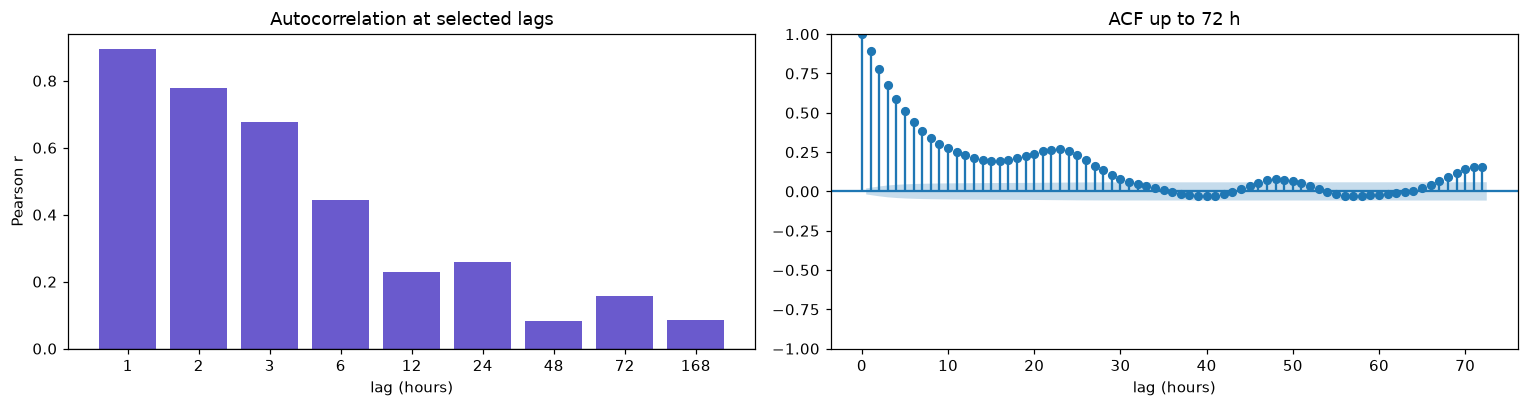

Reading the curve:
  - r decays from about 0.89 at 1 h to about 0.26 at 24 h.
  - it does NOT keep falling monotonically: at 24 h the value rises again.
    That bump is the diurnal cycle repeated one day later, not a 24-h memory.
  - beyond ~3 days the correlation is small, so features older than a few
    days are unlikely to help at the 3-24 h horizons we care about.


In [13]:
# Autocorrelation: for how many hours does the past still carry information?
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
acf = pd.Series({lag: hourly['wind_speed_ms'].autocorr(lag=lag) for lag in lags})

print('autocorrelation of hourly wind speed:')
print(acf.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].bar([str(l) for l in acf.index], acf.values, color='slateblue')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Autocorrelation at selected lags')
axes[0].set_xlabel('lag (hours)')
axes[0].set_ylabel('Pearson r')

if HAS_STATS:
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(hourly['wind_speed_ms'].dropna().values, lags=72, ax=axes[1])
    axes[1].set_title('ACF up to 72 h')
    axes[1].set_xlabel('lag (hours)')
else:
    dense = pd.Series({lag: hourly['wind_speed_ms'].autocorr(lag=lag) for lag in range(1, 73)})
    axes[1].plot(dense.index, dense.values, color='slateblue')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('ACF up to 72 h (pandas fallback - statsmodels not installed)')
    axes[1].set_xlabel('lag (hours)')
plt.tight_layout()
plt.show()

print('Reading the curve:')
print('  - r decays from about {:.2f} at 1 h to about {:.2f} at 24 h.'.format(acf[1], acf[24]))
print('  - it does NOT keep falling monotonically: at 24 h the value rises again.')
print('    That bump is the diurnal cycle repeated one day later, not a 24-h memory.')
print('  - beyond ~3 days the correlation is small, so features older than a few')
print('    days are unlikely to help at the 3-24 h horizons we care about.')

---

## 4. From a geoscience question to a machine-learning problem

### 4.1 The scientific question

> *Air-quality managers and wind-energy planners at Abali need to know the wind speed several hours to one day ahead, at the station itself.*

### 4.2 The machine-learning formulation

| Element | Decision for this course |
|---|---|
| Forecast origin | every hour `T` in the record |
| Target `y` | hourly mean wind speed at `T + H`, in m/s |
| Forecast horizons `H` | **3, 6, 12 and 24 hours** |
| Inputs (features) | variables observed at or before `T` (wind speed, direction, pressure, temperature, humidity, lags, rolling statistics, calendar) |
| Task type | **supervised regression** |
| Metrics | **MAE** (m/s) as the headline, **RMSE** (m/s) to penalise large errors, **MSE** for completeness, **R2** as a dimensionless summary |
| Reference point | **persistence** (`wind speed at T`) and **climatology** (the long-term mean) |

### 4.3 Why four horizons rather than one?

Because the difficulty of the problem *changes with the horizon*, and so does the usefulness of the predictors:

- at **3 h**, the current wind dominates; a persistence baseline is already decent;
- at **12 h**, the diurnal cycle becomes as informative as the current value;
- at **24 h**, the current value is little more than a seasonal hint, and the calendar plus the diurnal climatology carry most of the skill.

Only by evaluating all four horizons can you say something scientifically interesting in your report - e.g. *at what forecast range does our model stop beating persistence?*

### 4.4 Why metrics need units and a reference

- **MAE** is in m/s and is directly interpretable: 'our 6-hour forecast is typically off by 1.4 m/s'.
- **RMSE** is also in m/s but, because errors are squared, it is dominated by the rare windy hours.
- **R2** has no units and no physical meaning on its own; a negative R2 simply means the model is worse than predicting the training mean.
- **A metric without a baseline is uninterpretable.** 'MAE = 1.5 m/s' is neither good nor bad until you know that persistence gives 1.7 m/s.

We therefore always report the **skill score** relative to persistence:

```
skill = 1 - MAE_model / MAE_persistence
```

- `skill > 0`  ->  the model beats persistence.
- `skill = 0`  ->  the model is exactly as good as doing nothing.
- `skill < 0`  ->  the model is harmful, however impressive the R2 looks.

### 4.5 Two modelling setups you must not confuse

| Setup | Inputs available at time `T` | Realistic for |
|---|---|---|
| **Observation-driven (our setup)** | real measurements at `T` from the station itself | nowcasting and short-range station forecasting; the operational case of an isolated station with good telemetry |
| **NWP-driven** | *forecast* fields from a numerical model (e.g. ECMWF) valid at `T` | a forecast that must be issued hours or days before any observation exists |

Our setup is honest and unambiguous: *at time T we know the station's measurements up to and including T, and we predict the wind H hours later.* Every feature we build will be checked against that single sentence. In `04`-style research papers this is usually stated as:

> 'We use direct (multi-horizon) regression with observed predictors at the forecast origin.'

### 4.6 Direct or recursive multi-step forecasting?

- **Direct:** train a separate model per horizon; each model predicts `T + H` in one shot. Simple, fast, no error accumulation, and the one we use.
- **Recursive:** train one model for `T + 1` and feed its own prediction back as the next input. Errors compound, and every feature must be rebuilt from synthetic values.

For horizons of several hours to a day, direct is the safer and more standard choice. The trade-off is that model #3 and model #24 are different objects, which is exactly why we must evaluate each of them.

In [15]:
# Define the target explicitly and measure how hard each horizon is BEFORE modelling.
HORIZONS = [3, 6, 12, 24]
ws = hourly['wind_speed_ms']

rows = []
for H in HORIZONS:
    observed = ws.values[:-H]        # wind speed at the forecast origin T
    future = ws.values[H:]           # wind speed at T + H  -> the target y
    ok = ~np.isnan(observed) & ~np.isnan(future)
    err = future[ok] - observed[ok]  # persistence error: predict T+H with the value at T
    rows.append({
        'horizon_h': H,
        'n_pairs': int(ok.sum()),
        'corr_T_TplusH': float(np.corrcoef(observed[ok], future[ok])[0, 1]),
        'persistence_MAE': float(np.mean(np.abs(err))),
        'persistence_RMSE': float(np.sqrt(np.mean(err ** 2))),
    })

ref = pd.DataFrame(rows).set_index('horizon_h')
ref['climatology_MAE'] = float(np.mean(np.abs(ws - ws.mean())))
ref['climatology_RMSE'] = float(np.sqrt(np.nanmean((ws - ws.mean()) ** 2)))
ref['target_std'] = float(ws.std())
ref['persistence_skill_vs_climatology'] = 1.0 - ref['persistence_MAE'] / ref['climatology_MAE']

print('Reference skill of the two baselines we will have to beat:')
print(ref.round(3).to_string())
print()
print('Classification of each horizon:')
for H in HORIZONS:
    s = ref.loc[H, 'persistence_skill_vs_climatology']
    verdict = 'persistence is the benchmark to beat' if s > 0 else 'persistence is already WORSE than climatology'
    print('  H = {:>2d} h : skill of persistence = {:+.3f}  ->  {}'.format(H, s, verdict))

Reference skill of the two baselines we will have to beat:
           n_pairs  corr_T_TplusH  persistence_MAE  persistence_RMSE  climatology_MAE  climatology_RMSE  target_std  persistence_skill_vs_climatology
horizon_h                                                                                                                                            
3            10304          0.678            1.308             1.909            1.636             2.379       2.379                             0.200
6            10291          0.444            1.791             2.508            1.636             2.379       2.379                            -0.095
12           10267          0.228            2.134             2.958            1.636             2.379       2.379                            -0.305
24           10220          0.258            1.713             2.899            1.636             2.379       2.379                            -0.047

Classification of each horizon:
  H =  3

### 4.7 What this table already tells us

Read the numbers from the cell above with the following questions in mind.

1. **How fast does memory decay?** The correlation between `T` and `T+H` falls quickly, so a model that only sees the current wind speed will lose most of its power by 12-24 h.
2. **The baseline crossover.** Persistence beats climatology at the short horizons. At 12 h and 24 h the ordering can reverse, because after half a day the *average* wind is a better guess than the value six hours ago. This crossover is a classic result in wind forecasting and it defines the region where machine learning has real work to do.
3. **Why 24 h is not always harder than 12 h.** Look at the persistence RMSE at 24 h versus 12 h. The 24-hour lag compares the same hour of the day, so it inherits the diurnal cycle. That is a gift to persistence and a warning to us: at 24 h a *diurnal-climatology* baseline will be very competitive, and any model we build must beat **both** baselines, not just the easy one.
4. **Scale check.** All MAE values are well below the standard deviation of the target. Good forecasts of a highly variable quantity can still have large errors; the std column is the yardstick for judging whether the model has learned anything.

**Check for understanding:** a colleague reports `R2 = 0.31` for the 24 h model and calls it a success. What is missing from that claim? *A baseline. R2 alone cannot tell you whether you have beaten 'tomorrow = today'.*

---

## 5. Why not NetCDF and xarray?

Most geoscience ML courses start from gridded model output: a `.nc` file read with `xarray`, with dimensions `(time, latitude, longitude, level)`. That world comes with its own hazards - coordinate conventions, unit metadata, chunked access, and regridding - and much of the geoscience machine-learning literature works there.

**This project deliberately uses a different and equally realistic object: a single-station tabular time series.**

| | Gridded NetCDF | This project |
|---|---|---|
| Unit of analysis | grid point / field | a station's hourly record |
| Typical tooling | xarray, netCDF4, dask | pandas, an Excel export |
| Main hazards | coordinates, units, regridding | sentinels, irregular times, gaps |
| Target | a field | a scalar per time step |
| Feature content | neighbouring grid points | lags and windows of the *same* station |

Everything you learn here transfers: a gridded dataset that has been reduced to a time series at one point looks exactly like Abali. If you later move to ERA5 or a WRF output, the only new step is extracting the point/column and being consistent about time zones and units.

> **Practical note for your own work:** if you do move to xarray, read the attributes (`ds.attrs`, `da.units`) before you compute anything, and check that your time coordinate is monotonic and regular - the gridded equivalent of the grid check we performed above.

---

## 6. Common pitfalls in this session

**Pitfall 1 - treating the sentinel as data.**  
`-99999` in the humidity column survived into `mean()` and `std()` in our first table. The mean humidity was reported as ~12 % with a standard deviation of ~1956 %. Always print `min()` and `max()` before believing any summary statistic.

```python
# WRONG - the sentinel is treated as an extremely dry hour
df['humidity'].mean()
# RIGHT - mark impossible values as missing first
df.loc[df['humidity'] < 0, 'humidity'] = np.nan
```

**Pitfall 2 - assuming the file is sorted.**  
The export is newest-first. Any `shift`, `rolling`, `diff` or `cumsum` applied before sorting produces a mirror image of reality.

**Pitfall 3 - letting gaps disappear.**  
`resample().mean()` on a series with a gap silently produces a shorter series: a six-hour outage disappears and 'the previous hour' becomes 'seven hours ago'. We reindex onto a full hourly grid so that gaps remain visible as `NaN`.

```python
# WRONG - the outage is invisible
df.set_index('datetime').resample('1h').mean()
# RIGHT - force a complete grid, then handle NaN explicitly
df.resample('1h').mean().reindex(pd.date_range(start, end, freq='h'))
```

**Pitfall 4 - interpolating whatever is missing.**  
Filling the target variable is fabricating the very quantity you claim to predict. Interpolate *inputs*, never the target.

**Pitfall 5 - treating wind direction as a linear number.**  
Averaging degrees is meaningless, and using degrees as a feature creates a false 359-vs-1 gap. Use `sin`/`cos` (or a wind rose for *display* only).

**Pitfall 6 - reporting a metric without a baseline.**  
An MAE of 1.3 m/s sounds impressive until you notice that persistence gives 1.35 m/s.

**Pitfall 7 - writing cleaned data to disk 'so I do not have to clean it twice'.**  
In this course we deliberately rebuild the clean series from the raw file in every notebook, in memory. It removes an entire class of stale-file mistakes (an old CSV silently surviving a change to the cleaning rules) and it makes each notebook reproducible on its own. In production you would of course version a *pipeline*, not a frozen CSV.

**Pitfall 8 - `df.sample()` and `train_test_split(shuffle=True)`.**  
They destroy the temporal order and produce absurdly optimistic scores. Session 2 replaces them with a chronological split.

---

## 7. AI-assisted workflow

You are expected to use an LLM as a working tool in this course - and to *verify* everything it produces. The rules are the same as for a human collaborator: it must be checkable, and you are responsible for the final text and code.

### 7.1 Prompts that work well for scientific code

| Goal | Example prompt |
|---|---|
| Understand an unfamiliar file | 'I have an Excel export from a met station with a column `DateTimes` stored as text like `2025-03-10 23:50:10` at 10-minute resolution. Write pandas code to parse it, verify the sampling interval, and report gaps. Do not write any file to disk.' |
| Get the science right | 'Why is treating wind direction in degrees as a linear feature problematic in regression? Give a concrete numeric example and the standard encoding.' |
| Reproduce a paper | 'Explain how the persistence skill score is defined for wind forecasting and what a value of 0.2 means physically.' |
| Ask for a check, not a solution | 'Here is my cleaning function. List the ways it could still leak future information into a feature. Do not rewrite it; just list the risks.' |

### 7.2 A debugging prompt template

```
I am running this code: <paste code>
On this data: <paste 5-10 rows and the dtypes>
I expected: <expected result>
I got: <actual result and the full traceback>
The environment is Python <x>, pandas <y>.
Give me the most likely cause first, then how to verify it, then the fix.
```

The key ingredient is *the smallest reproduction that fails*. Never paste a whole notebook and ask 'why is it broken?'.

### 7.3 A code-review prompt template

```
Act as a reviewer for a geoscience machine-learning paper.
Review this data-preparation function for:
  (a) data leakage (any use of information after the forecast origin),
  (b) statistical errors (sentinel handling, circular variables, gap handling),
  (c) reproducibility risks (random seeds, hard-coded paths, hidden state).
Quote the specific line for each issue and rate its severity. Do not rewrite the code.
```

### 7.4 Validation checklist - apply it to every AI answer

1. **Does it run?** Paste it into a throwaway cell and execute it. 'Looks plausible' is not evidence.
2. **Does the API exist?** LLMs invent plausible method names (for example a `resample_hourly()` convenience function that does not exist). Type `?pd.DataFrame.resample` in Jupyter, or read the official documentation page.
3. **Are the numbers plausible physically?** A wind speed of 250 m/s, a humidity of 1956 % or an R2 of 0.999 are all red flags.
4. **Is the leakage rule respected?** Check every `shift`, `rolling`, `fillna` and `split` by hand. This is the single most common way AI-generated time-series code is wrong: it happily uses `shuffle=True` because that is the idiom in ordinary tabular tutorials.
5. **Is the answer specific to our data?** Advice written for the 1-minute UCI bike-sharing dataset does not transfer to 10-minute station data with real gaps.
6. **Can you reproduce the claim from the documentation?** If the explanation cites a behaviour ('pandas drops NaN by default in rolling'), verify it in a cell rather than trusting the prose.

### 7.5 A worked example of a *bad* answer

Prompt: *'Write a function to fill missing wind speed in an hourly weather dataset.'*

Plausible-sounding but wrong answer:

```python
df['wind_speed'] = df['wind_speed'].fillna(df['wind_speed'].mean())
```

Three problems: it uses a global mean (which includes *future* hours relative to any forecast origin, and so leaks), it flattens the variance in a way that distorts the target distribution, and it applies to the **target**, which is exactly what we must never fabricate. A better answer distinguishes inputs from the target, uses only past information for any imputation, and documents how many values were changed.

### 7.6 Exercise in using AI responsibly

Take the `load_abali_hourly` function above and ask an LLM to criticise it. Then decide, for each criticism, whether it is correct, irrelevant, or wrong - and record your reasoning in a markdown cell. You will do a fuller version of this in Session 6.

---

## 8. Exercises

### Level 1 - understanding

1. How many raw rows are there, and how many hours do they represent? Why is the number of hourly rows not exactly `raw_rows / 6`?
2. Which variable in this dataset is missing most often? Suggest two physical or technical reasons.
3. Is the wind-speed distribution symmetric? What does the sign of the skewness mean physically?
4. Write down, in one sentence, the definition of the target variable for `H = 6`.

### Level 2 - implementation

5. Reproduce the missing-value pattern as an image (rows = variables, columns = time) and describe where humidity outages cluster.
6. Compute the fraction of hours with `wind_speed_ms == 0` separately for day (06-18) and night (19-05). Does the difference look physical?
7. Compute the *circular* mean direction per month using `arctan2(sin, cos)` and compare it with the naive arithmetic mean.
8. Add an hourly series of `wind_speed_ms` resampled with the median instead of the mean, and compare the two series. Would the median be a better hourly target?
9. Build the same reference table as in section 4 but with `H = 1, 2, 48, 72`. Where does persistence stop being useful?

### Level 3 - reasoning

10. The persistence baseline beats climatology at 3 h but loses at 12 h. Explain in your own words why, and describe what a good model must do at each of those horizons.
11. Suppose we deleted every row with a missing humidity value. How many rows would we lose, and which season would be hit hardest? Why is deleting rows in a *training* set not the same as deleting them in a *test* set?
12. A colleague proposes using `n_obs` (the number of 10-minute records per hour) as a feature. Give one reason why it might help and one reason why it is dangerous. Which argument wins?

### Level 4 - application (project work)

13. **Write your problem statement.** In a markdown cell, produce a one-page definition of the project containing: (a) the scientific question, (b) the target variable and its units, (c) the four horizons, (d) the inputs available at the forecast origin, (e) the metrics, (f) the baselines that must be beaten. This text will be the opening section of your Session 7 report.
14. Justify the choice of *hourly* resolution instead of 10-minute resolution in three sentences, mentioning at least one consequence for feature engineering and one for evaluation.

---

## 9. Reproducibility notes

- **Single source of truth.** `data/raw/abali.xlsx`, read-only. No cleaned CSV, no intermediate export, no second station.
- **Seeds.** `SEED = 42` is set once. This session uses no randomness, but later sessions do (tree ensembles, subsampling), so the seed is established here.
- **Environment.** The notebook prints the version of every library it uses in the setup cell. Record that output in your report - `pandas 3.x` and `pandas 1.x` differ in places that matter for time series.
- **Determinism of the cleaning.** Every step is a pure function of the raw file: same file in, same hourly series out. The function is defined in the notebook, so a change to the cleaning rules cannot silently survive in a stale artefact.
- **Nothing is written.** Verify this at the end of the session: `data/cleaned/` must not gain a new file from your run.
- **Documented judgement calls.** Three decisions were made in this notebook and each one belongs in the methods section of your report:
  1. sentinels and out-of-range values are set to `NaN` (not imputed);
  2. the target is never interpolated, auxiliary variables are interpolated over gaps of at most 2 h;
  3. the record is analysed at hourly resolution.

---

## 10. Key takeaways

1. A geoscience question became a precise regression problem: predict the hourly mean wind speed 3, 6, 12 and 24 hours ahead, from observations available at the forecast origin.
2. The raw file is 10-minute data, newest-first, containing sentinels and irregular timestamps. Auditing it before modelling is not optional.
3. Cleaning happens in memory: sentinels and impossible values to `NaN`, duplicates removed, then hourly averaging onto a perfect grid so that gaps stay visible.
4. Wind speed is right-skewed with a strong diurnal cycle and a clear seasonal contrast; wind direction is circular and must be encoded as `sin`/`cos`.
5. Persistence is a strong baseline at short horizons; its dominance fades around half a day, and it is not always the hardest baseline - at 24 h a diurnal climatology is a serious competitor.
6. Every number we will report later is judged against those baselines.

In [16]:
# ===========================================================================
# FINAL VALIDATION CELL - run last, in every notebook
# ===========================================================================
WARNINGS = []
if not HAS_SNS:
    WARNINGS.append('seaborn not installed: correlation panel drawn with matplotlib imshow')
if not HAS_STATS:
    WARNINGS.append('statsmodels not installed: ACF drawn from pandas autocorr instead of plot_acf')
if int(hourly['wind_speed_ms'].isna().sum()) > 0:
    WARNINGS.append('{} hourly wind-speed values are missing and are left as NaN by design'.format(
        int(hourly['wind_speed_ms'].isna().sum())))
if int((hourly['wind_speed_ms'] == 0).sum()) > 0:
    WARNINGS.append('{} hours report exactly 0.00 m/s (possible calm or stuck anemometer); not removed'.format(
        int((hourly['wind_speed_ms'] == 0).sum())))

manifest = {
    'notebook': '01_problem_definition_and_eda_abali.ipynb',
    'session': 'Session 1 - problem definition and exploratory data analysis',
    'dataset_used': RAW_PATH + ' (Abali station, 10-minute records, read-only, single source)',
    'target_variable': 'hourly mean wind speed (wind_speed_ms, m/s) at time T+H',
    'forecast_horizons_hours': HORIZONS,
    'models_used': 'none - this session defines the problem and characterises the data',
    'metrics_used': 'descriptive statistics; persistence and climatology MAE/RMSE as reference',
    'records': {'raw_10min': int(len(raw)), 'clean_hourly': int(len(hourly))},
    'time_range_hourly': [str(hourly.index.min()), str(hourly.index.max())],
    'leakage_checks': ['raw file sorted chronologically before any shift/rolling',
                       'target wind speed never interpolated',
                       'n_obs quality flag excluded from features'],
    'files_written': 'none (all cleaning in memory)',
    'random_seed': SEED,
    'warnings': WARNINGS,
}
print(json.dumps(manifest, indent=2, default=str))

{
  "notebook": "01_problem_definition_and_eda_abali.ipynb",
  "session": "Session 1 - problem definition and exploratory data analysis",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, 10-minute records, read-only, single source)",
  "target_variable": "hourly mean wind speed (wind_speed_ms, m/s) at time T+H",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "models_used": "none - this session defines the problem and characterises the data",
  "metrics_used": "descriptive statistics; persistence and climatology MAE/RMSE as reference",
  "records": {
    "raw_10min": 61353,
    "clean_hourly": 10440
  },
  "time_range_hourly": [
    "2024-01-01 00:00:00",
    "2025-03-10 23:00:00"
  ],
  "leakage_checks": [
    "raw file sorted chronologically before any shift/rolling",
    "target wind speed never interpolated",
    "n_obs quality flag excluded from features"
  ],
  "files_written": "none (all cleaning in memory)",
  "random_seed": 42,
  "warnings": [
  

---

### What comes next

In **Session 2** we turn this clean hourly series into a leakage-safe modelling table and split it chronologically:

- lag and rolling-window features that respect the forecast origin;
- calendar and cyclical (`sin`/`cos`) encodings;
- the leakage audit - what future information looks like when it hides in a feature;
- a **purged chronological** train / validation / test split for the 3, 6, 12 and 24 h horizons.

Before you continue, complete at least exercises 5, 10 and 13. Exercise 13 (the problem statement) is the opening section of your final report.